# Haar Functions

Here we are giving visual tests of the haar coefficient functions from the haar file that I wrote. The tests
are visual in that we simply plot the graphs of the functions as well as the graphs of what is obtained
via haar decomposition. This is, in fact, kind of trivial since we use the fact that things like 
$<f,h_Q>h_Q$ can be computed in terms of averages on children minus averages on parent. So realy then 
what we have is a telescoping sum where the result is the values of the function at the smallest scale
(i.e. the data given to the create_haar function) minus the average of f. So then if we just add the 
average back to the partial haar decomposition we just get back what we put in. 

On the other hand, this assures us things are programmed correctly. It also let's us get the absolute values
of the haar coefficients which is useful in various things. For example, we can do things like throw out the
haar coefficients that do not contribute much. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
from My_Solvers.pde_solvers import fdm
from My_Solvers.haar import create_haar, create_haar_2d

In [2]:
def f(x):
    #return np.where(x < 0.25, 1, 2)
    return np.cos(x)**np.exp(np.cos(40*x**2))
    #return x**2
Num = 6
N = 2**Num
X = np.linspace(1/(2*N), 1 - 1/(2*N), N)
Y = f(X)

A, H, C = create_haar(Y)

First, plot the haar transform and the given function and compare. 

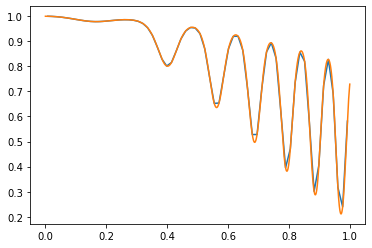

In [3]:
Z = np.zeros(H.shape[1])
for k in range(H.shape[0]):
    Z += H[k,:]
Z += A[-1,:]
plt.plot(X, Z)
plt.plot(np.linspace(0,1, 2**(16)), f(np.linspace(0,1, 2**(16))))

Now add noise and use Haars to de--noise. But first plot the noisy signal.

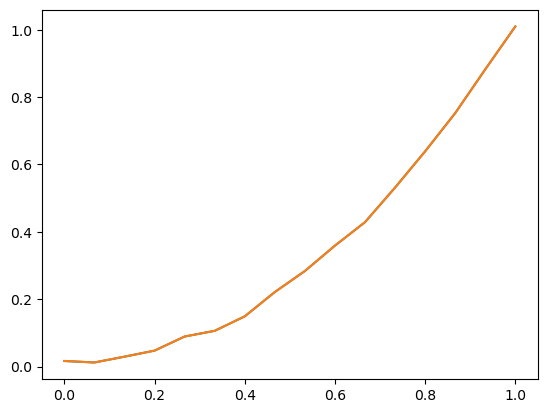

In [689]:
Yn = Y + np.random.normal(0, .01, size = Y.shape)
An, Hn, Cn = create_haar(Yn)
Zn = np.zeros(Hn.shape[1])
Xn = np.linspace(0,1,Zn.size)
for k in range(Hn.shape[0]):
    Zn += Hn[k,:]
Zn += An[-1,:]
plt.plot(Xn, Zn)
plt.plot(Xn, Yn)

C is the matrix of coefficients. So find where those are "big" and delete the corresponding values from H.

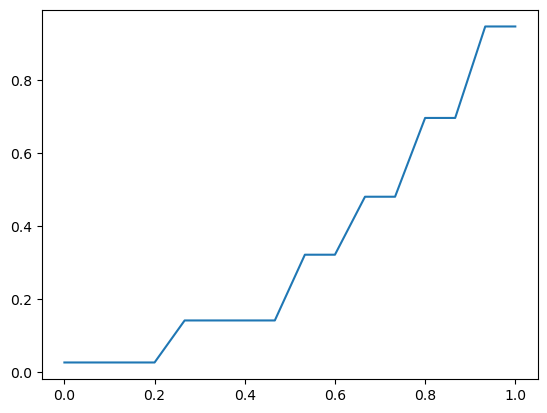

In [690]:
th = .1 * np.max(np.abs(Cn))
Hdn = np.where(np.abs(Cn) >= th, Hn, 0)
#Hdn = H * Cdn

Zdn = np.zeros(Hdn.shape[1])
Xn = np.linspace(0,1,Zn.size)
for k in range(Hn.shape[0]):
    Zdn += Hdn[k,:]
Zdn += An[-1,:]
plt.plot(Xn, Zdn)
#plt.plot(Xn, Yn)
#plt.plot(X, Y)

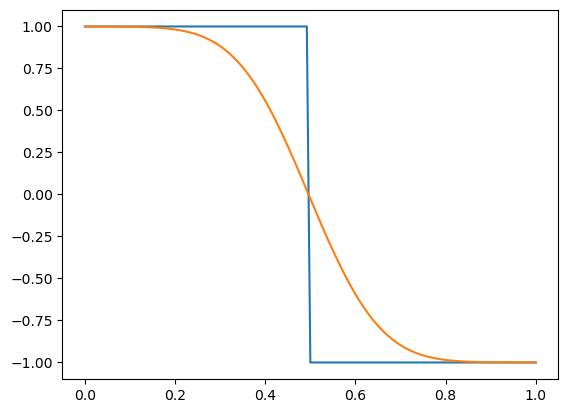

In [55]:
def haar(x):
    return np.where(x < .5, 1, -1)
def haar2(x):
    return np.sqrt(2)*haar(2*x)
T1, X1, U1 = fdm(haar, 1, 1/2**Num, 1/128, 1, lbc = [0,1,0], rbc = [0,1,0])

plt.plot(X1, haar(X1))

plt.plot(X1,U1[-1,])

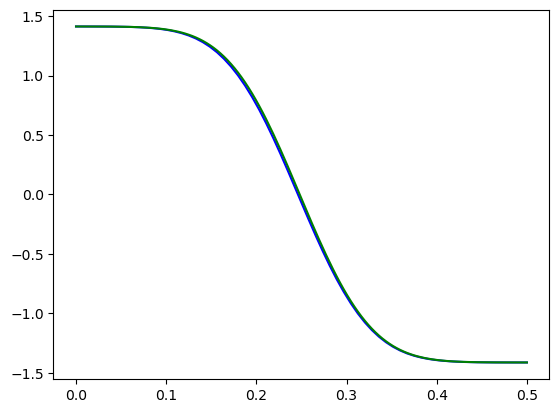

In [57]:
T2, X2, U2 = fdm(haar2, 1, 1/2**Num, .25/128, 1/2, lbc = [0,1,0], rbc = [0,1,0])
plt.plot(X2,U2[-1,], color = 'blue')
plt.plot(np.linspace(0,.5, U1[-1,].size), np.sqrt(2)*U1[-1,], color = 'green')
#plt.plot(X2, haar2(X2))

In [2]:
Num = 2
N = 2**Num
x = np.linspace(1/(2*N), 1 - 1/(2*N), N)
y = np.linspace(1/(2*N), 1 - 1/(2*N), N)
X, Y = np.meshgrid(x, y)

def g(x, y):
    return -x**2 + y**3 + np.exp(np.cos(x**2 + np.exp(y)))

Z = g(X, Y)

A, H, C, Z = create_haar_2d(Z)

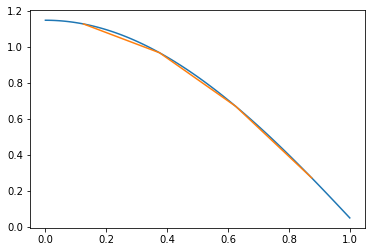

In [3]:
idx = 3
def fx(x):
    return g(x, Y[idx,0])
xx = np.linspace(0, 1, 100)
plt.plot(xx, fx(xx))
plt.plot(X[0], Z[idx])

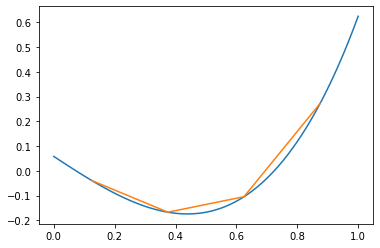

In [4]:
idx = 3
def fy(y):
    return g(X[0,idx], y)
yy = np.linspace(0, 1, 100)
plt.plot(yy, fy(yy))
plt.plot(Y[:,0], Z[:,idx])

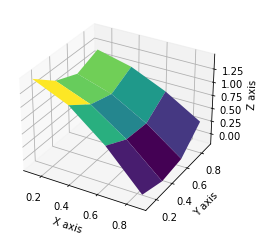

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

XX, YY = np.meshgrid(xx, yy)

# Plot the surface
ax.plot_surface(X, Y, Z, cmap='viridis')
#ax.plot_surface(XX, YY, g(XX, YY), cmap='plasma')

# Optional: plot wireframe
# ax.plot_wireframe(X, Y, Z, color='black')

# Labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

plt.show()